<a href="https://colab.research.google.com/github/hasinduwelikala/northstar-databases-analytics/blob/main/02_R_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
install.packages("ggplot2",    repos = "https://cran.r-project.org", quiet = TRUE)
install.packages("dplyr",      repos = "https://cran.r-project.org", quiet = TRUE)
install.packages("corrplot",   repos = "https://cran.r-project.org", quiet = TRUE)
install.packages("ggcorrplot", repos = "https://cran.r-project.org", quiet = TRUE)

library(ggplot2)
library(dplyr)
library(corrplot)
library(ggcorrplot)

In [21]:
base_url <- "https://raw.githubusercontent.com/hasinduwelikala/northstar-databases-analytics/main/data/"

files <- c("orders.csv", "deliveries.csv", "hubs.csv", "customers.csv",
           "complaints.csv", "drivers.csv", "vehicles.csv", "incidents.csv",
           "app_events.csv", "data_dictionary.csv", "README.txt")

for (f in files) download.file(paste0(base_url, f), destfile = f, quiet = TRUE)
cat("All files downloaded.\n")

All files downloaded.


In [22]:
orders     <- read.csv("orders.csv",     stringsAsFactors = FALSE, na.strings = "")
drivers    <- read.csv("drivers.csv",    stringsAsFactors = FALSE, na.strings = "")
vehicles   <- read.csv("vehicles.csv",   stringsAsFactors = FALSE, na.strings = "")
incidents  <- read.csv("incidents.csv",  stringsAsFactors = FALSE, na.strings = "")
deliveries <- read.csv("deliveries.csv", stringsAsFactors = FALSE, na.strings = "")
customers  <- read.csv("customers.csv",  stringsAsFactors = FALSE, na.strings = "")
complaints <- read.csv("complaints.csv", stringsAsFactors = FALSE, na.strings = "")
hubs       <- read.csv("hubs.csv",       stringsAsFactors = FALSE, na.strings = "")
cat("All data frames loaded.\n")

All data frames loaded.


In [24]:
orders <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
drivers <- read.csv("drivers.csv")
vehicles <- read.csv("vehicles.csv")
incidents <- read.csv("incidents.csv")
customers <- read.csv("customers.csv")
hubs <- read.csv("hubs.csv")

cat("Data loaded successfully\n")

Data loaded successfully



=== Driver Statistics ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  40.60   68.55   75.20   74.91   82.75   99.00       7 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.150   3.905   4.175   4.172   4.478   5.000 

Average Driver Rating: 4.171706 


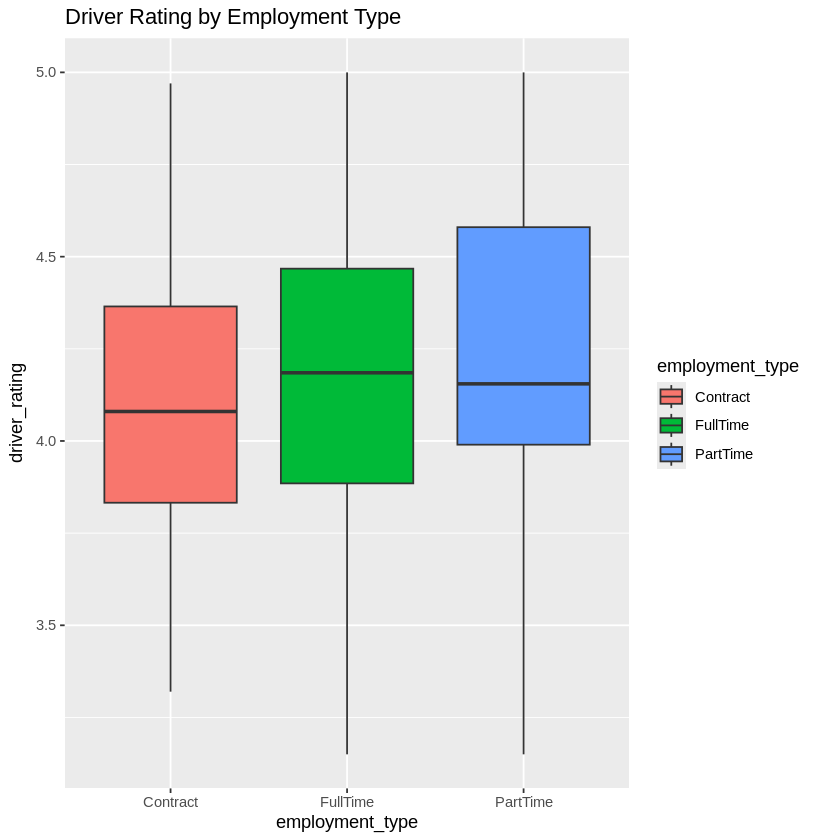

In [25]:
cat("\n=== Driver Statistics ===\n")

summary(drivers$training_score)
summary(drivers$driver_rating)

cat("Average Driver Rating:",
    mean(drivers$driver_rating, na.rm = TRUE), "\n")


ggplot(drivers,
       aes(x = employment_type,
           y = driver_rating,
           fill = employment_type)) +
  geom_boxplot() +
  labs(title = "Driver Rating by Employment Type")


=== Correlation Analysis ===

	Pearson's product-moment correlation

data:  drivers$training_score and drivers$driver_rating
t = -0.88848, df = 161, p-value = 0.3756
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.22119671  0.08477949
sample estimates:
        cor 
-0.06985133 



`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 7 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 7 rows containing missing values or values outside the scale range
(`geom_point()`).”


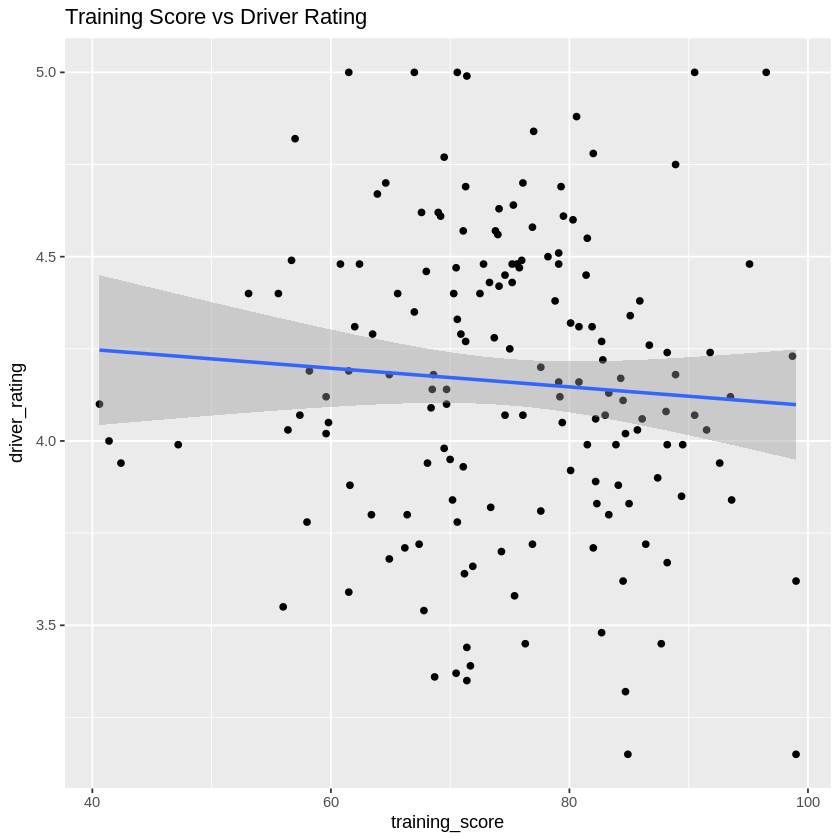

In [26]:
cat("\n=== Correlation Analysis ===\n")

cor_result <- cor.test(
  drivers$training_score,
  drivers$driver_rating
)

print(cor_result)

ggplot(drivers,
       aes(x = training_score,
           y = driver_rating)) +
  geom_point() +
  geom_smooth(method = "lm") +
  labs(title = "Training Score vs Driver Rating")


=== Vehicle Battery Health ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  42.00   68.20   78.05   76.79   85.78  100.00       4 


  High Risk Medium Risk     Healthy 
          0          35          81 

Warning message:
“Removed 4 rows containing non-finite outside the scale range (`stat_bin()`).”


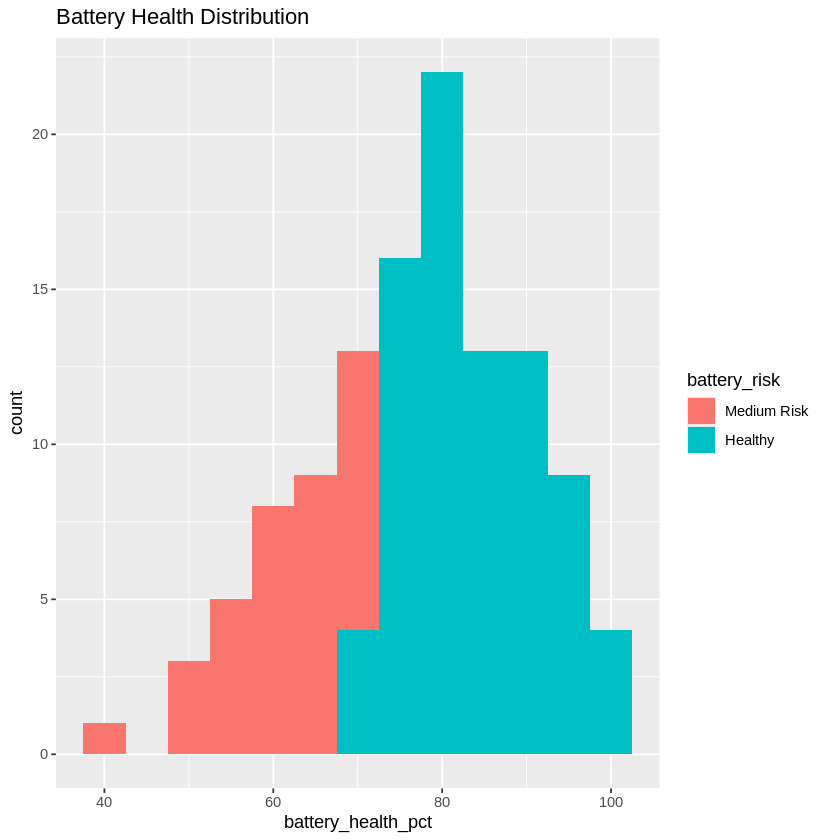

In [27]:
cat("\n=== Vehicle Battery Health ===\n")

summary(vehicles$battery_health_pct)

vehicles$battery_risk <- cut(
  vehicles$battery_health_pct,
  breaks = c(0,40,70,100),
  labels = c("High Risk","Medium Risk","Healthy")
)

table(vehicles$battery_risk)


ggplot(vehicles,
       aes(x = battery_health_pct,
           fill = battery_risk)) +
  geom_histogram(binwidth = 5) +
  labs(title = "Battery Health Distribution")


=== Route Overrides Analysis ===


Delayed    Failed    OnTime 
1.0742574 1.0378788 0.9204545

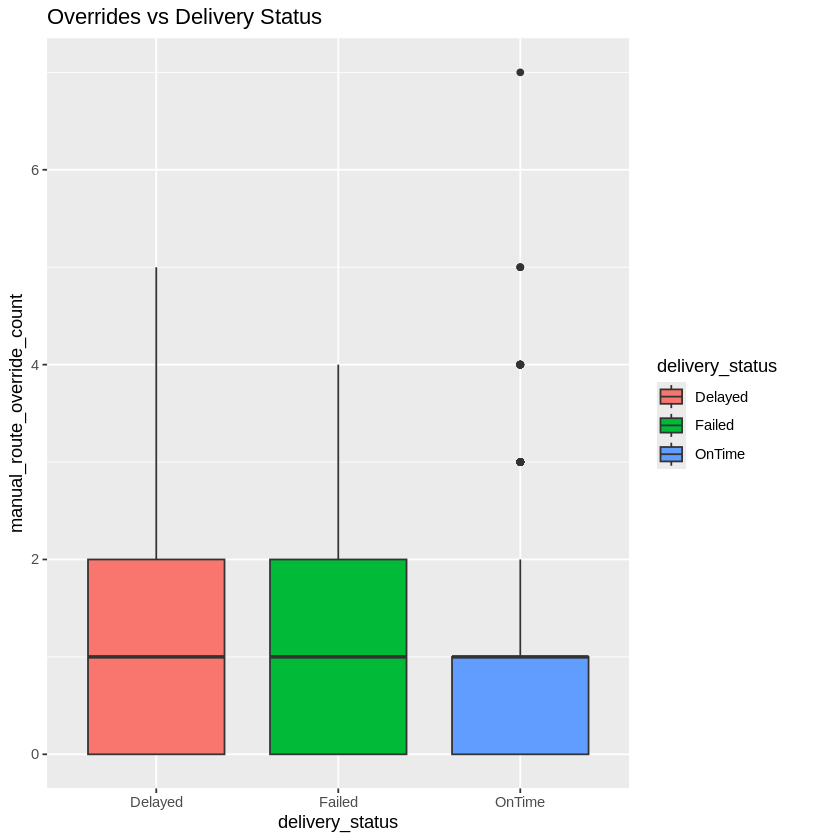

In [28]:
cat("\n=== Route Overrides Analysis ===\n")

base <- merge(deliveries, orders, by = "order_id")


tapply(base$manual_route_override_count,
       base$delivery_status,
       mean)

ggplot(base,
       aes(x = delivery_status,
           y = manual_route_override_count,
           fill = delivery_status)) +
  geom_boxplot() +
  labs(title = "Overrides vs Delivery Status")

In [29]:
cat("\n=== Incident Resolution Analysis ===\n")

tapply(incidents$resolved_hours,
       incidents$resolution_status,
       mean)

anova_model <- aov(
  resolved_hours ~ resolution_status,
  data = incidents
)

summary(anova_model)


=== Incident Resolution Analysis ===


Closed     Escalated          Open PendingVendor 
           NA            NA            NA            NA

                   Df Sum Sq Mean Sq F value Pr(>F)
resolution_status   3    183   61.00   1.015  0.386
Residuals         259  15558   60.07               
17 observations deleted due to missingness


=== Hub Performance ===
  hub_id manual_route_override_count
1    H01                   1.0294118
2    H02                   0.9150943
3    H03                   0.8907563
4    H04                   0.8740157
5    H05                   0.9478261
6    H06                   0.9134615
7    H07                   1.0521739
8    H08                   1.1093750


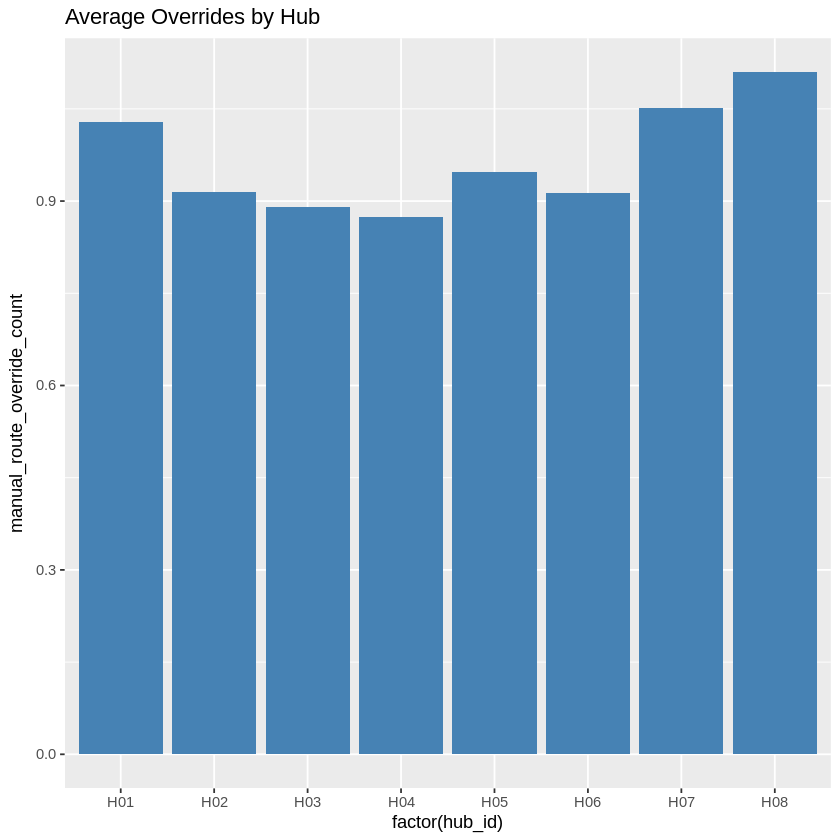

In [30]:
cat("\n=== Hub Performance ===\n")

hub_perf <- aggregate(
  manual_route_override_count ~ hub_id,
  data = base,
  mean
)

print(hub_perf)

ggplot(hub_perf,
       aes(x = factor(hub_id),
           y = manual_route_override_count)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(title = "Average Overrides by Hub")


=== Profitability Analysis ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  -9.42   36.08   64.11   79.02  109.73  489.52 

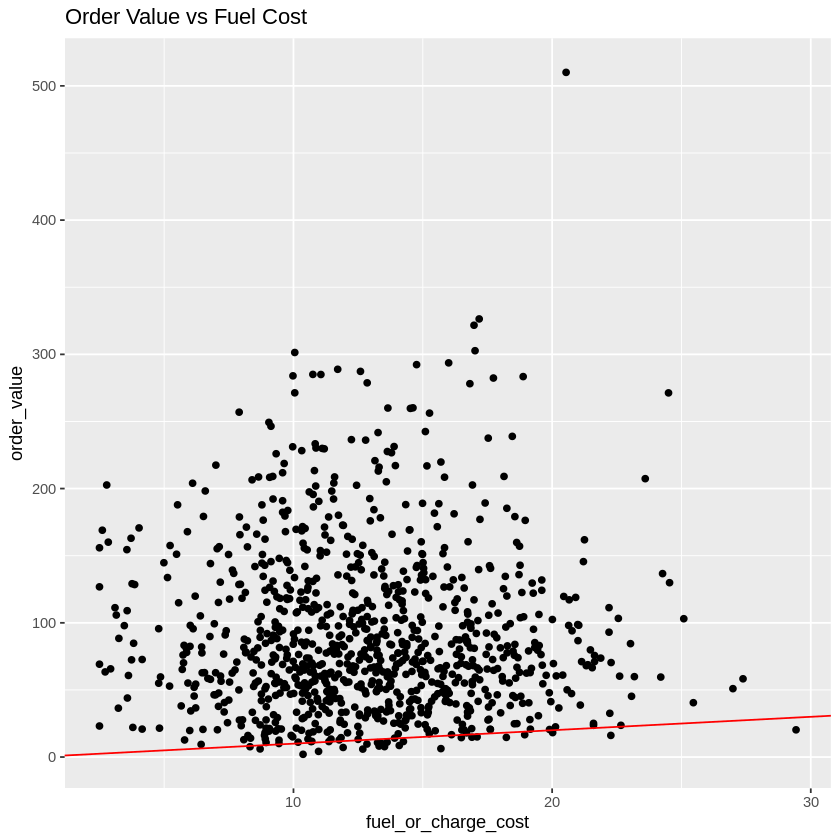

In [31]:
cat("\n=== Profitability Analysis ===\n")

profit_base <- merge(
  deliveries,
  orders[, c("order_id","order_value")],
  by = "order_id"
)

profit_base$profit_margin <-
  profit_base$order_value -
  profit_base$fuel_or_charge_cost

summary(profit_base$profit_margin)

# Scatter Plot
ggplot(profit_base,
       aes(x = fuel_or_charge_cost,
           y = order_value)) +
  geom_point() +
  geom_abline(slope = 1, intercept = 0, color = "red") +
  labs(title = "Order Value vs Fuel Cost")

In [33]:
cat("\n=== Driver Incident Analysis ===\n")

inc_count <- as.data.frame(table(incidents$delivery_id))
colnames(inc_count) <- c("delivery_id","incident_count")

driver_data <- merge(deliveries, drivers, by = "driver_id")
driver_data <- merge(driver_data, inc_count, by = "delivery_id", all.x = TRUE)

driver_data$incident_count[
  is.na(driver_data$incident_count)
] <- 0

cor.test(
  driver_data$driver_rating,
  driver_data$incident_count
)


=== Driver Incident Analysis ===



	Pearson's product-moment correlation

data:  driver_data$driver_rating and driver_data$incident_count
t = -0.075242, df = 948, p-value = 0.94
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.06603777  0.06117006
sample estimates:
         cor 
-0.002443744 



=== Customer Loyalty Analysis ===


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  13.10   49.00   59.60   59.69   70.45   99.00      20 


	Pearson's product-moment correlation

data:  customers$loyalty_score and customers$app_engagement_score
t = 0.8944, df = 628, p-value = 0.3715
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.04256479  0.11346559
sample estimates:
       cor 
0.03566776 


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 20 rows containing missing values or values outside the scale range
(`geom_point()`).”



=== Analytics Completed Successfully ===


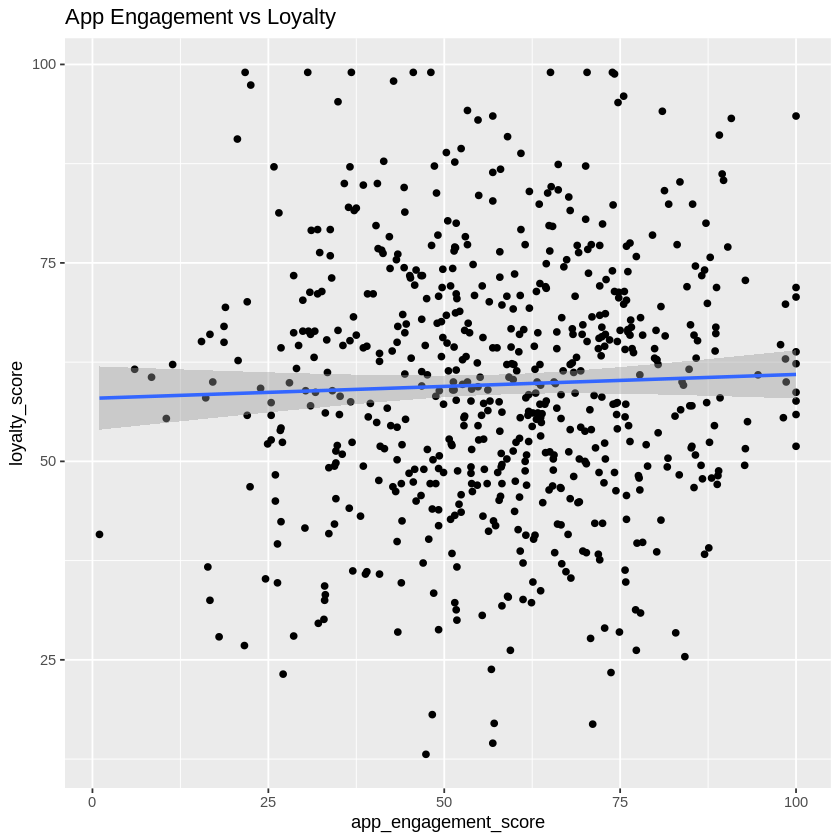

In [34]:
cat("\n=== Customer Loyalty Analysis ===\n")

summary(customers$loyalty_score)

cor.test(
  customers$loyalty_score,
  customers$app_engagement_score
)

# Scatter Plot
ggplot(customers,
       aes(x = app_engagement_score,
           y = loyalty_score)) +
  geom_point() +
  geom_smooth(method = "lm") +
  labs(title = "App Engagement vs Loyalty")

cat("\n=== Analytics Completed Successfully ===\n")